In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns   
import os 
import plotly.express as px
import plotly.graph_objects as go
import kagglehub
import os 
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency



c:\Users\rafae\Documents\Projetos Vscode\Doenças\Infarto\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\rafae\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1


In [3]:
print (os.listdir(path))

['healthcare-dataset-stroke-data.csv']


In [4]:
arquivo = os.path.join(path, "healthcare-dataset-stroke-data.csv")

df = pd.read_csv(arquivo)
df.head()
    

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
df.isnull().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [9]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [11]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

### Tratamento das Variáveis 

In [10]:
df = df.drop(columns=["id"])

In [11]:
df["stroke"].value_counts(normalize=True)*100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Distribuição de Acidentes Vasculares Cerebrais')

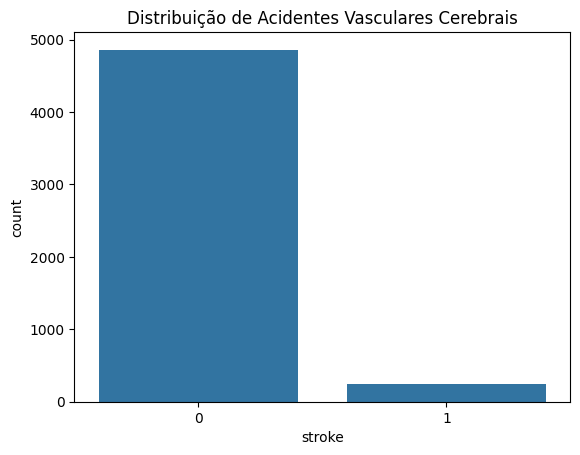

In [12]:
sns.countplot(x="stroke", data=df)
plt.title("Distribuição de Acidentes Vasculares Cerebrais")

## Idade

<Axes: xlabel='age', ylabel='Count'>

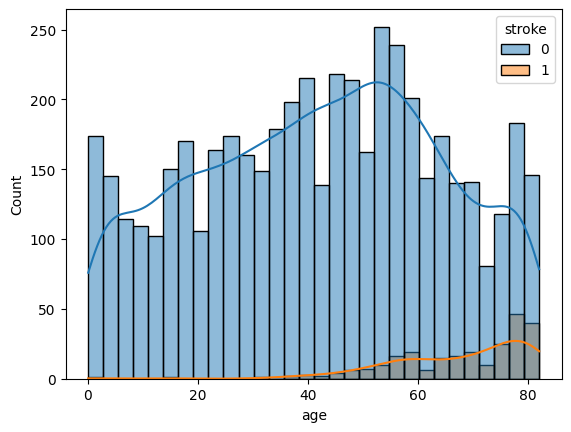

In [13]:
sns.histplot(
    data=df,
    x="age",
    hue="stroke",
    kde=True,
    bins=30
)

In [14]:
stroke_0 = df[df["stroke"] == 0]["age"]
stroke_1 = df[df["stroke"] == 1]["age"]

stat, p = mannwhitneyu(
    stroke_0,
    stroke_1,
    alternative="two-sided"
)

print("p-value:", p)

p-value: 3.726634665900011e-71


In [15]:
df.groupby("stroke")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,41.971545,22.291940,0.08,24.0,43.0,59.0,82.0
1,249.0,67.728193,12.727419,1.32,59.0,71.0,78.0,82.0


In [16]:
df["faixa_idade"] = pd.cut(
    df["age"],
    bins=[0,30,40,50,60,70,120]
)

In [17]:
pd.crosstab(
    df["faixa_idade"],
    df["stroke"],
    normalize="index"
)*100

stroke,0,1
faixa_idade,,
"(0, 30]",99.872611,0.127389
"(30, 40]",99.109792,0.890208
"(40, 50]",97.970230,2.029770
"(50, 60]",94.046173,5.953827
"(60, 70]",91.750842,8.249158
"(70, 120]",81.971831,18.028169


In [18]:
df.groupby("stroke")["avg_glucose_level"].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,104.795513,43.846069,55.12,77.12,91.47,112.83,267.76
1,249.0,132.544739,61.921056,56.11,79.79,105.22,196.71,271.74


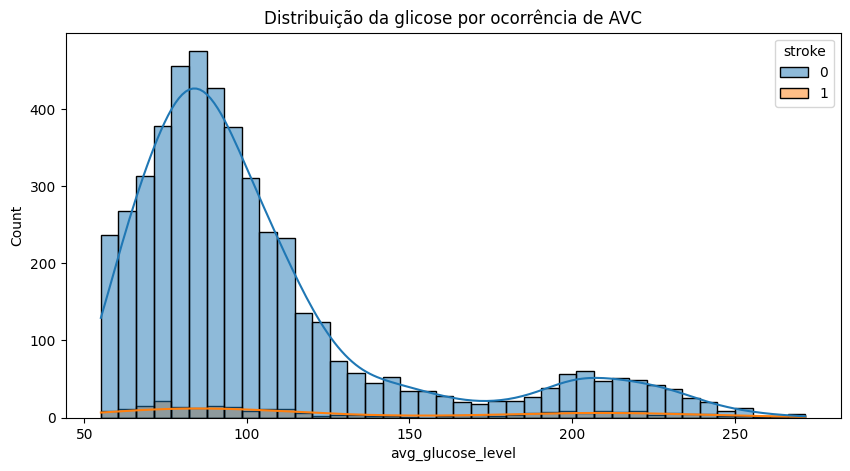

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="avg_glucose_level",
    hue="stroke",
    kde=True,
    bins=40
)

plt.title("Distribuição da glicose por ocorrência de AVC")
plt.show()

In [20]:

stroke_0_glicose = df[df["stroke"] == 0]["avg_glucose_level"]
stroke_1_glicose = df[df["stroke"] == 1]["avg_glucose_level"]

stat, p = mannwhitneyu(
    stroke_0_glicose,
    stroke_1_glicose,
    alternative="two-sided"
)

print("p-value:", p)

p-value: 3.6403672710893236e-09


In [21]:
df.groupby("stroke")["avg_glucose_level"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,count,mean,median,std,min,max
stroke,,,,,,
0,4861,104.795513,91.47,43.846069,55.12,267.76
1,249,132.544739,105.22,61.921056,56.11,271.74


### BMI 

In [22]:
df["bmi"].isnull().sum()

np.int64(201)

In [23]:
df.groupby("stroke")["bmi"].apply(
    lambda x: x.isnull().mean() * 100
)

stroke
0     3.312076
1    16.064257
Name: bmi, dtype: float64

In [24]:
df["bmi_missing"] = df["bmi"].isnull().astype(int)

In [25]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [26]:
pd.crosstab(
    df["bmi_missing"],
    df["stroke"]
)

stroke,0,1
bmi_missing,,
0,4700,209
1,161,40


In [27]:
tabela = pd.crosstab(
    df["bmi_missing"],
    df["stroke"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("p-value:", p)

p-value: 3.107748528644105e-23


In [28]:
stroke_0_bmi = df[df["stroke"] == 0]["bmi"].dropna()
stroke_1_bmi = df[df["stroke"] == 1]["bmi"].dropna()

stat, p = mannwhitneyu(
    stroke_0_bmi,
    stroke_1_bmi,
    alternative="two-sided"
)

print("p-value:", p)

p-value: 0.0002769039186472648


In [29]:
df.groupby("stroke")["bmi"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,count,mean,median,std,min,max
stroke,,,,,,
0,4861,28.799115,28.1,7.777269,10.3,97.6
1,249,30.090361,28.1,5.861877,16.9,56.6


# Machine Learning 

In [10]:
X = df.drop(columns=["stroke"])

In [11]:
y = df["stroke"]